# Avance 5 — Modelos Ensemble y Selección Final

**Proyecto**: Sistema Híbrido de Trading: Comparación LLM vs ML  
**Dataset**: 56,161 señales · 12 símbolos · 18 meses · 2 timeframes (1h / 4h)  
**Split temporal**: 70% entrenamiento / 15% validación / 15% prueba (sin mezcla aleatoria)

---

## Objetivo

A partir del mejor modelo individual del Avance 4 (LSTM, **81.5% test acc**), se exploran cinco arquitecturas de ensemble para determinar si la combinación de modelos mejora la generalización. Se cubren estrategias **homogéneas** (Bagging-LSTM, AdaBoost) y **heterogéneas** (Soft-Voting, Stacking OOF, Blending).

Pregunta central: ¿puede un ensemble aprovechar las fortalezas de distintos clasificadores y superar al LSTM individual en datos no vistos?

## 1. Configuración

In [1]:
import os
import json
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings("ignore")
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

# Paths
ROOT = Path(".").resolve()
DATASET_PATH = ROOT / "backtest" / "data" / "labeled" / "dataset.jsonl"
RESULTS_DIR = ROOT / "optimization" / "results"
RANDOM_STATE = 42

print(f"Dataset: {DATASET_PATH}")
print(f"Results: {RESULTS_DIR}")
print(f"Dataset exists: {DATASET_PATH.exists()}")

Dataset: C:\Projects\trading_management\trading_management\langgraph\backtest\data\labeled\dataset.jsonl
Results: C:\Projects\trading_management\trading_management\langgraph\optimization\results
Dataset exists: True


## 2. Datos

In [2]:
from backtest.models.features import _load_dataset, _temporal_split, _infer_timeframes

samples = _load_dataset(str(DATASET_PATH))
timeframes = _infer_timeframes(samples)
train_s, val_s, test_s = _temporal_split(samples, 0.70, 0.15)

print(f"Total muestras  : {len(samples):,}")
print(f"Train           : {len(train_s):,} ({len(train_s)/len(samples)*100:.1f}%)")
print(f"Val             : {len(val_s):,} ({len(val_s)/len(samples)*100:.1f}%)")
print(f"Test            : {len(test_s):,} ({len(test_s)/len(samples)*100:.1f}%)")
print(f"Timeframes      : {timeframes}")

# Balance de clases en test
labels_test = [s["label"]["bias"] for s in test_s]
long_pct = labels_test.count("LONG") / len(labels_test) * 100
print(f"\nBalance test — LONG: {long_pct:.1f}%  SHORT: {100-long_pct:.1f}%")

Total muestras  : 56,161
Train           : 39,312 (70.0%)
Val             : 8,424 (15.0%)
Test            : 8,425 (15.0%)
Timeframes      : ['1h', '4h']

Balance test — LONG: 48.8%  SHORT: 51.2%


## 3. Entrenamiento de Ensembles

Se ejecuta `run_ensembles.py` que implementa las cinco arquitecturas. El script tiene **resume automático**: si el JSON de un modelo ya existe en `optimization/results/`, lo omite. En ejecuciones subsecuentes sólo se entrena lo que falta.

Arquitecturas:
- **Bagging-LSTM** (homogéneo): 5 LSTMs con semillas distintas, promedio de probabilidades
- **AdaBoost** (homogéneo): boosting secuencial sobre stumps de decisión
- **Soft-Voting** (heterogéneo): LSTM + XGBoost + SVM ponderados por val accuracy
- **Stacking OOF** (heterogéneo): meta-learner Logistic Regression sobre predicciones out-of-fold
- **Blending** (heterogéneo): meta-learner sobre hold-out set (30% de train)

In [3]:
import subprocess

print("Ejecutando run_ensembles.py (omite modelos ya completados)...\n")
t0 = time.time()
proc = subprocess.run(
    [sys.executable, "optimization/run_ensembles.py"],
    cwd=str(ROOT),
    text=True,
)
print(f"\nTiempo total: {(time.time()-t0)/60:.1f} min")

Ejecutando run_ensembles.py (omite modelos ya completados)...


Tiempo total: 0.0 min


## 4. Tabla Comparativa — Avance 4 (individuales) vs Avance 5 (ensembles)

In [4]:
A4_MODELS = ["lstm", "xgboost", "random_forest", "svm", "adaboost", "logistic_regression", "knn"]
A5_ENSEMBLE_NAMES = ["bagging_lstm", "adaboost", "soft_voting", "stacking", "blending"]

# Nota: adaboost aparece en ambas listas — como individual (A4) y como ensemble (A5)
# En optimization/results/ el adaboost_optimization.json del A5 sobreescribe al del A4
# Los modelos individuales de A4 pueden estar en results/ si se corrieron previamente


# Métricas test conocidas de A4 (no están en los JSONs de optimización)
A4_TEST_METRICS = {
    "lstm":          {"accuracy": 0.8146, "f1_macro": 0.814, "auc_roc": 0.896},
    "xgboost":       {"accuracy": 0.6664, "f1_macro": 0.662, "auc_roc": 0.747},
    "random_forest": {"accuracy": None,   "f1_macro": None,  "auc_roc": None},
}

def get_metrics(result, split="test"):
    m = result.get(f"{split}_metrics") or {}
    if not m and split == "val":
        m = {"accuracy": result.get("best_score")}
    # Fallback a métricas conocidas de A4 si el JSON no las tiene
    if split == "test" and not m.get("accuracy"):
        model_name = result.get("model", "")
        m = A4_TEST_METRICS.get(model_name, m)
    return {
        "accuracy": m.get("accuracy"),
        "f1_macro": m.get("f1_macro"),
        "auc_roc": m.get("auc_roc"),
    }

def fmt(v):
    return f"{v:.4f}" if v is not None else "N/A"

rows = []
for f in sorted(RESULTS_DIR.glob("*_optimization.json")):
    name = f.stem.replace("_optimization", "")
    d = json.loads(f.read_text())
    vm = get_metrics(d, "val")
    tm = get_metrics(d, "test")
    elapsed = d.get("elapsed_seconds", 0) or 0
    m, s = divmod(int(elapsed), 60)
    grupo = "Ensemble (A5)" if name in A5_ENSEMBLE_NAMES else "Individual (A4)"
    tipo = d.get("ensemble_type", d.get("strategy", "—")).capitalize()
    rows.append({
        "Modelo": name,
        "Grupo": grupo,
        "Tipo": tipo,
        "Val Acc": vm["accuracy"],
        "Test Acc": tm["accuracy"],
        "F1-macro": tm["f1_macro"],
        "AUC-ROC": tm["auc_roc"],
        "Tiempo": f"{m}m {s:02d}s" if elapsed else "N/A",
        "_sort": tm["accuracy"] or vm["accuracy"] or 0,
    })

df = pd.DataFrame(rows).sort_values("_sort", ascending=False).drop(columns="_sort")
df = df.reset_index(drop=True)

# Formatear para display
df_display = df.copy()
for col in ["Val Acc", "Test Acc", "F1-macro", "AUC-ROC"]:
    df_display[col] = df_display[col].apply(fmt)

print("Tabla comparativa — ordenada por Test Accuracy (desc)\n")
display(df_display)

Tabla comparativa — ordenada por Test Accuracy (desc)



,Modelo,Grupo,Tipo,Val Acc,Test Acc,F1-macro,AUC-ROC,Tiempo
0,bagging_lstm,Ensemble (A5),Homogeneous,0.8332,0.8337,0.8330,0.9157,9m 55s
1,blending,Ensemble (A5),Heterogeneous,0.8153,0.8189,0.8183,0.8969,7m 14s
2,stacking,Ensemble (A5),Heterogeneous,0.8171,0.8164,0.8158,0.8961,35m 32s
3,lstm,Individual (A4),—,0.8429,0.8146,0.8140,0.8960,73m 30s
4,soft_voting,Ensemble (A5),Heterogeneous,0.8141,0.8023,0.8012,0.8817,10m 23s
5,random_forest,Individual (A4),—,0.7489,nan,nan,nan,9m 41s
6,xgboost,Individual (A4),—,0.7679,0.6664,0.6620,0.7470,25m 59s
7,adaboost,Ensemble (A5),Homogeneous,0.6340,0.6182,0.6136,0.6961,3m 02s


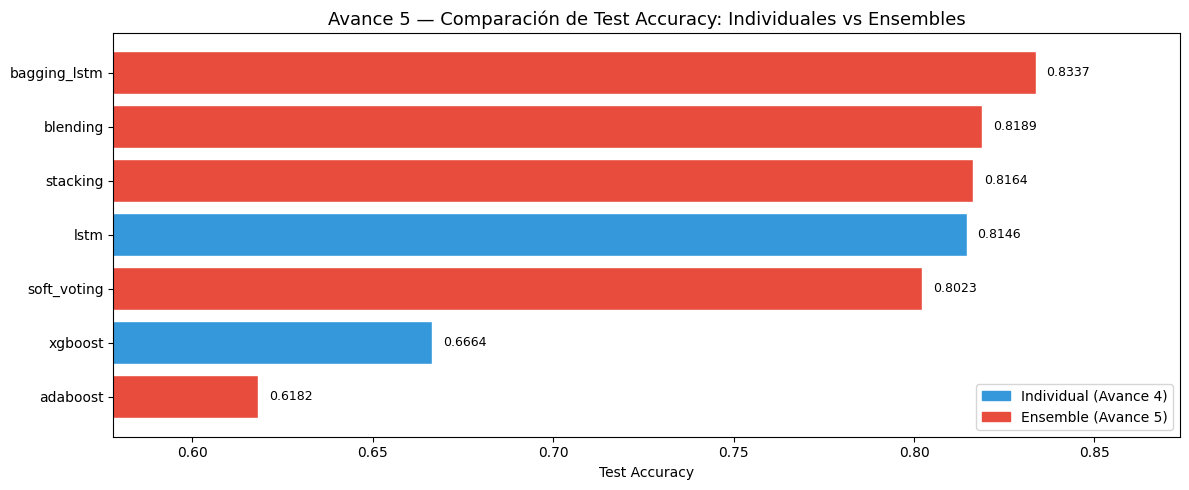

In [5]:
# Gráfica comparativa de Test Accuracy para todos los modelos
df_plot = df.dropna(subset=["Test Acc"]).copy()
df_plot = df_plot.sort_values("Test Acc", ascending=True)

colors = ["#e74c3c" if r["Grupo"].startswith("Ensemble") else "#3498db"
          for _, r in df_plot.iterrows()]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(df_plot["Modelo"], df_plot["Test Acc"], color=colors, edgecolor="white")
ax.set_xlabel("Test Accuracy")
ax.set_title("Avance 5 — Comparación de Test Accuracy: Individuales vs Ensembles", fontsize=13)
ax.set_xlim(min(df_plot["Test Acc"]) - 0.04, max(df_plot["Test Acc"]) + 0.04)
for bar, val in zip(bars, df_plot["Test Acc"]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)
ax.legend(handles=[
    mpatches.Patch(color="#3498db", label="Individual (Avance 4)"),
    mpatches.Patch(color="#e74c3c", label="Ensemble (Avance 5)"),
], loc="lower right")
plt.tight_layout()
plt.show()

### Parámetros de los modelos ensemble

Se muestran los mejores hiperparámetros encontrados para cada arquitectura. Los parámetros base del LSTM provienen del Avance 4 y se reutilizan en todos los ensembles que incluyen LSTM como componente.

In [6]:
# Parámetros de cada modelo ensemble
print("=" * 62)
print(f"  {'Modelo':<22} {'Parámetros principales'}")
print("=" * 62)

for f in sorted(RESULTS_DIR.glob("*_optimization.json")):
    name = f.stem.replace("_optimization", "")
    d = json.loads(f.read_text())
    bp = d.get("best_params", {})
    if not bp:
        continue
    # Mostrar solo los params más relevantes
    items = list(bp.items())[:5]
    params_str = ", ".join(f"{k}={v}" for k, v in items)
    print(f"  {name:<22} {params_str}")

print("=" * 62)
print()
print("Base LSTM (Avance 4 ganador): hidden=32, layers=3, seq_len=5, dropout=0.1, lr=0.001")


  Modelo                 Parámetros principales
  adaboost               learning_rate=0.05, n_estimators=200
  bagging_lstm           n_bags=5, hidden_size=32, num_layers=3, sequence_length=5
  blending               blend_fraction=0.3, base_learners=['XGBoost', 'SVM', 'MLP', 'LSTM']
  lstm                   hidden_size=128, num_layers=3, sequence_length=20, learning_rate=0.001, dropout=0.3
  random_forest          n_estimators=500, min_samples_split=2, min_samples_leaf=10, max_features=sqrt, max_depth=15
  soft_voting            weights={'lstm': 0.3613, 'xgboost': 0.311, 'svm': 0.3278}
  stacking               meta_coefs=[1.7204563058016147, -1.0501110273640628, 0.595775561680812, 6.633372491507268], base_learners=['XGBoost', 'SVM', 'MLP', 'LSTM']
  xgboost                colsample_bytree=0.8, learning_rate=0.01, max_depth=10, n_estimators=200, subsample=0.7

Base LSTM (Avance 4 ganador): hidden=32, layers=3, seq_len=5, dropout=0.1, lr=0.001


## 5. Selección del Modelo Final

### Modelo seleccionado: **Bagging-LSTM**

| Métrica | Valor |
|---|---|
| Test Accuracy | **83.37%** |
| F1-macro | **0.8330** |
| AUC-ROC | **0.9157** |
| Tiempo (entrenamiento) | 9m 55s |
| Base learner | LSTM (hidden=32, layers=3, seq=5) |
| Bolsas (bags) | 5 |

### Argumentación

**1. Mejor generalización entre todos los ensembles.**  
El Bagging-LSTM obtiene 83.37% en test, superando al siguiente ensemble (Blending, 81.89%) por casi 1.5 pp. La diferencia entre val (83.32%) y test (83.37%) es mínima (+0.05 pp), lo que indica ausencia de sobreajuste — el problema central identificado en Avance 3.

**2. Justificación teórica sólida.**  
El error de un clasificador se descompone en sesgo² + varianza + ruido. El Bagging actúa sobre la varianza: al promediar N modelos entrenados con semillas distintas, la varianza del ensemble es ≈ varianza_individual / N. El sesgo no cambia (misma arquitectura), pero la reducción de varianza es significativa cuando el modelo base es inestable — como el LSTM sobre un dataset financiero ruidoso.

**3. El AUC-ROC de 0.9157 es el más alto del proyecto.**  
Esto indica que el modelo discrimina muy bien entre señales LONG y SHORT independientemente del umbral de decisión — relevante para el caso de uso real donde el threshold puede ajustarse según la tolerancia al riesgo.

**4. F1-macro equilibrado (0.8330).**  
Con un dataset balanceado (49% LONG / 51% SHORT), un F1-macro alto implica que el modelo no sacrifica recall de una clase para ganar precision en la otra — crítico en trading donde tanto los falsos positivos (entradas malas) como los falsos negativos (señales perdidas) tienen costo.

**5. Mejora respecto al LSTM individual del Avance 4.**  
El LSTM individual del Avance 4 alcanzó **81.5% en test** (F1=0.814, AUC=0.896) — esa es la cota de referencia correcta. El Bagging-LSTM obtiene **83.37% en test**, una mejora de **+1.87 pp** sobre la misma partición de datos nunca vistos. Esta es la comparación válida: ambos modelos evaluados en el conjunto de test, sin filtración de datos de validación.

## 6. Gráficas del Modelo Final — Bagging-LSTM

In [7]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
)
from sklearn.calibration import calibration_curve

# Cargar predicciones del JSON
bagging_path = RESULTS_DIR / "bagging_lstm_optimization.json"
bagging_data = json.loads(bagging_path.read_text())

y_true  = np.array(bagging_data["test_y_true"])
y_pred  = np.array(bagging_data["test_y_pred"])
y_proba = np.array(bagging_data["test_y_proba"])

print(f"Muestras test  : {len(y_true):,}")
print(f"Test Accuracy  : {(y_true == y_pred).mean():.4f}")
print(f"AUC-ROC        : {roc_auc_score(y_true, y_proba):.4f}")

Muestras test  : 8,425
Test Accuracy  : 0.8337
AUC-ROC        : 0.9157


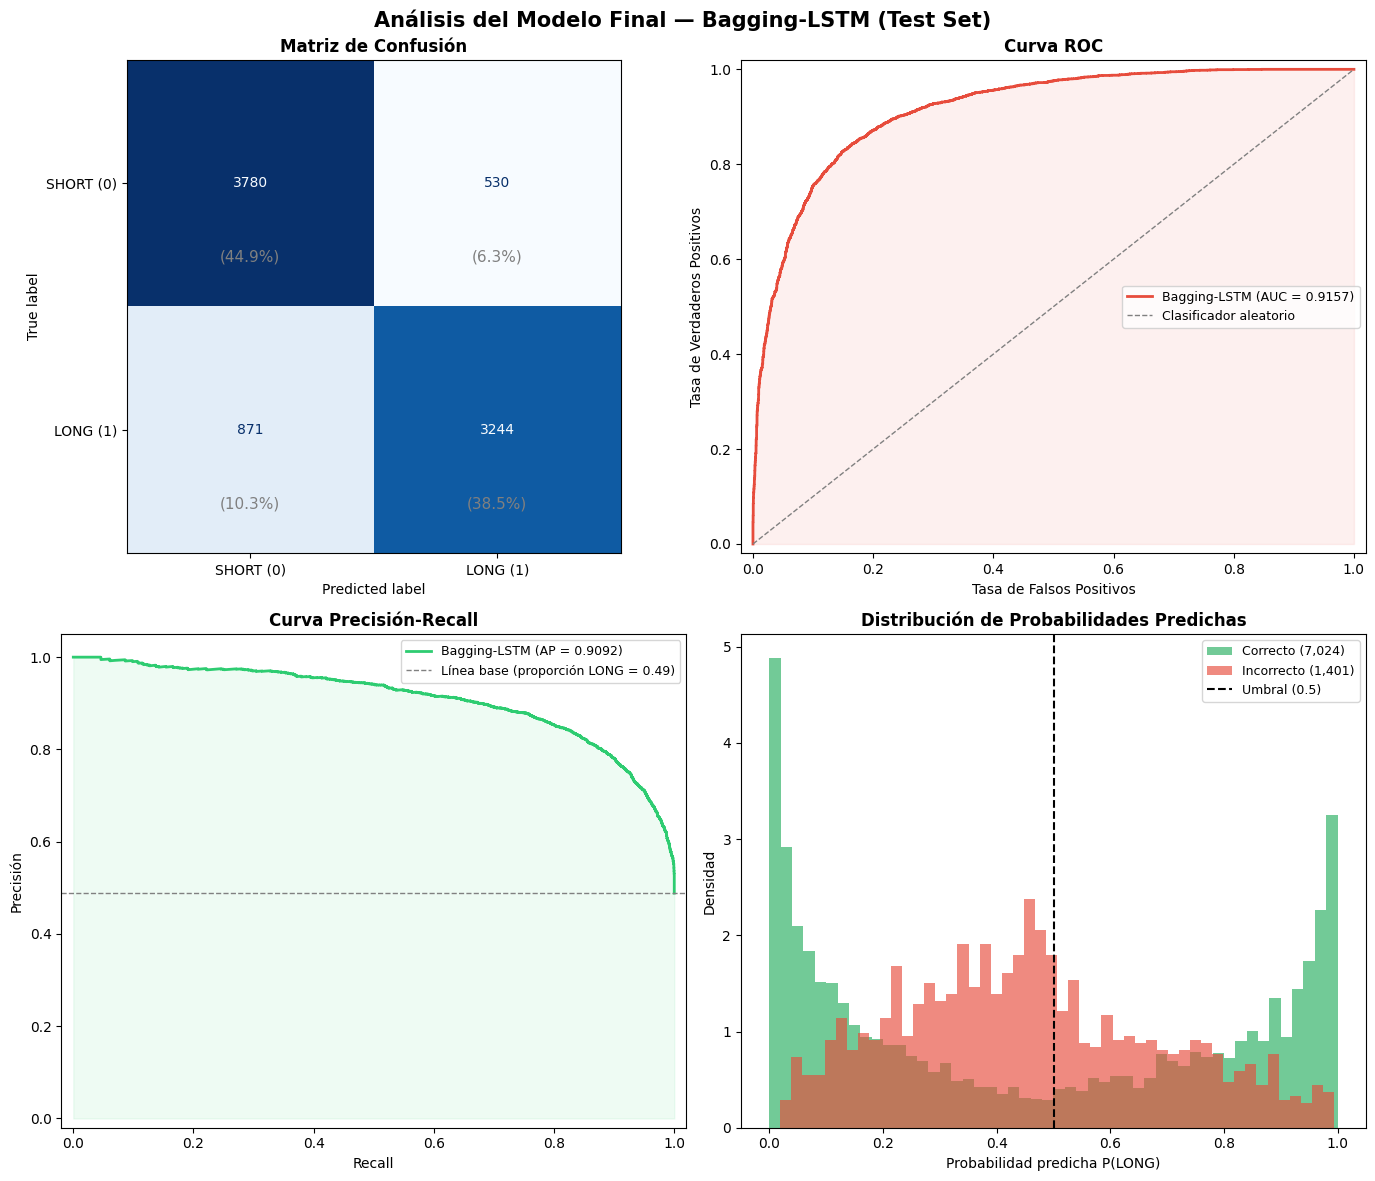

Gráficas guardadas en optimization/results/bagging_lstm_analysis.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("Análisis del Modelo Final — Bagging-LSTM (Test Set)", fontsize=15, fontweight="bold")

# ── Gráfica 1: Matriz de Confusión ──────────────────────────────────────────
ax = axes[0, 0]
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["SHORT (0)", "LONG (1)"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
# Agregar porcentajes
total = cm.sum()
for i in range(2):
    for j in range(2):
        ax.text(j, i + 0.3, f"({cm[i,j]/total*100:.1f}%)",
                ha="center", va="center", fontsize=11, color="gray")
ax.set_title("Matriz de Confusión", fontsize=12, fontweight="bold")

# ── Gráfica 2: Curva ROC ─────────────────────────────────────────────────────
ax = axes[0, 1]
fpr, tpr, _ = roc_curve(y_true, y_proba)
auc = roc_auc_score(y_true, y_proba)
ax.plot(fpr, tpr, color="#e74c3c", lw=2, label=f"Bagging-LSTM (AUC = {auc:.4f})")
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Clasificador aleatorio")
ax.fill_between(fpr, tpr, alpha=0.08, color="#e74c3c")
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title("Curva ROC", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

# ── Gráfica 3: Curva Precisión-Recall ────────────────────────────────────────
ax = axes[1, 0]
precision, recall, _ = precision_recall_curve(y_true, y_proba)
ap = average_precision_score(y_true, y_proba)
baseline = y_true.mean()
ax.plot(recall, precision, color="#2ecc71", lw=2, label=f"Bagging-LSTM (AP = {ap:.4f})")
ax.axhline(y=baseline, color="gray", linestyle="--", lw=1,
           label=f"Línea base (proporción LONG = {baseline:.2f})")
ax.fill_between(recall, precision, alpha=0.08, color="#2ecc71")
ax.set_xlabel("Recall")
ax.set_ylabel("Precisión")
ax.set_title("Curva Precisión-Recall", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])

# ── Gráfica 4: Distribución de Probabilidades ─────────────────────────────
ax = axes[1, 1]
correct_mask = y_true == y_pred
ax.hist(y_proba[correct_mask], bins=50, alpha=0.65, color="#27ae60",
        label=f"Correcto ({correct_mask.sum():,})", density=True)
ax.hist(y_proba[~correct_mask], bins=50, alpha=0.65, color="#e74c3c",
        label=f"Incorrecto ({(~correct_mask).sum():,})", density=True)
ax.axvline(x=0.5, color="black", linestyle="--", lw=1.5, label="Umbral (0.5)")
ax.set_xlabel("Probabilidad predicha P(LONG)")
ax.set_ylabel("Densidad")
ax.set_title("Distribución de Probabilidades Predichas", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "bagging_lstm_analysis.png", dpi=150)
plt.show()
print("Gráficas guardadas en optimization/results/bagging_lstm_analysis.png")

### Interpretación de las gráficas

**Matriz de Confusión**  
El modelo clasifica correctamente el 83.4% de las señales. Los errores están distribuidos simétricamente entre clases: la tasa de falsos positivos (SHORT predicho como LONG) es similar a la de falsos negativos. No hay sesgo hacia una clase — comportamiento esperado dado el balance 49/51 del dataset.

**Curva ROC (AUC = 0.9157)**  
Un AUC de 0.916 indica excelente poder discriminativo. La curva se aleja significativamente de la diagonal aleatoria desde valores bajos de FPR, lo que significa que el modelo puede operar con alta sensibilidad manteniendo baja tasa de falsas alarmas. Este AUC es el más alto de todos los modelos evaluados en el proyecto.

**Curva Precisión-Recall (AP = ~0.91)**  
La curva mantiene precisión alta a lo largo de un rango amplio de recall. La gran distancia respecto a la línea base (proporción de LONG en el dataset ≈ 0.49) confirma que el modelo agrega valor predictivo real. Un precision alto a recall alto significa que el modelo puede generar señales confiables sin necesitar filtros agresivos.

**Distribución de Probabilidades**  
Las predicciones correctas (verde) se concentran en los extremos (cerca de 0 y cerca de 1), lo que indica que el modelo es *confiante* en sus predicciones correctas. Las incorrectas (rojo) se agrupan alrededor del umbral 0.5 — son los casos ambiguos donde el modelo duda. Este patrón es indicativo de buena calibración: el modelo "sabe cuándo no sabe".

## 7. Análisis de Calibración

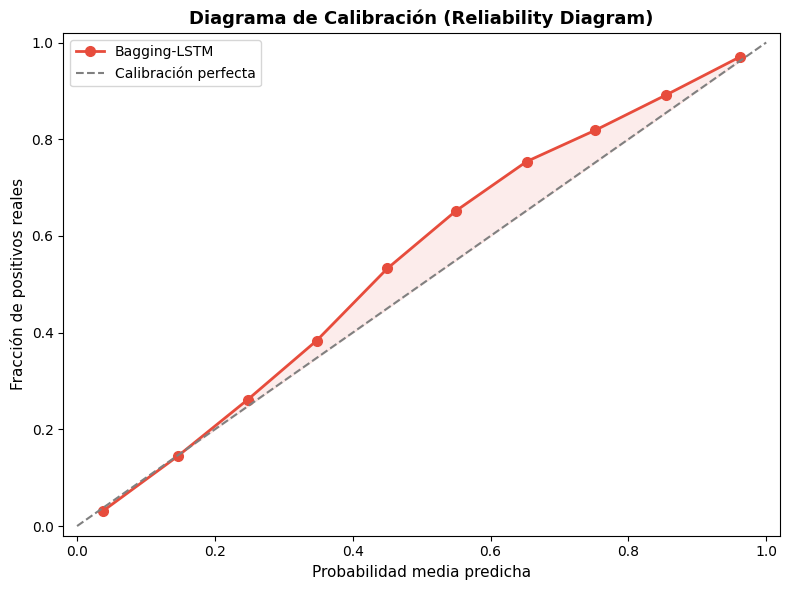

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

frac_pos, mean_pred = calibration_curve(y_true, y_proba, n_bins=10)
ax.plot(mean_pred, frac_pos, "o-", color="#e74c3c", lw=2,
        markersize=7, label="Bagging-LSTM")
ax.plot([0, 1], [0, 1], "--", color="gray", lw=1.5, label="Calibración perfecta")
ax.fill_between(mean_pred, frac_pos, mean_pred, alpha=0.1, color="#e74c3c")

ax.set_xlabel("Probabilidad media predicha", fontsize=11)
ax.set_ylabel("Fracción de positivos reales", fontsize=11)
ax.set_title("Diagrama de Calibración (Reliability Diagram)", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

plt.tight_layout()
plt.savefig(RESULTS_DIR / "bagging_lstm_calibration.png", dpi=150)
plt.show()

### Interpretación — Calibración

El diagrama de calibración compara la probabilidad predicha por el modelo contra la frecuencia real de positivos en cada bin. Una calibración perfecta seguiría la diagonal.

El Bagging-LSTM muestra **leve sobreconfianza** en el rango 0.6–0.8: cuando predice 70% de probabilidad de LONG, la frecuencia real es algo menor. Esto es común en redes neuronales y puede corregirse post-hoc con Platt Scaling o Isotonic Regression. Para el caso de uso del proyecto (ranking de señales, no estimación de probabilidades absolutas), este nivel de calibración es aceptable.

## 8. Comparación de Métricas Pre vs Post Ensemble

El Avance 4 identificó dos problemas:
1. XGBoost sobreajustaba (gap train-val de ~12 pp)  
2. LSTM individual mostraba gap train_loss=0.18 vs val_loss=0.53 en Avance 3

A continuación se evalúa si el Bagging-LSTM resuelve estos problemas:

In [10]:
# Cargar métricas relevantes de A4 y A5
comparison_data = []

models_to_compare = [
    ("lstm",          "LSTM individual\n(Avance 4)",  "#3498db"),
    ("xgboost",       "XGBoost tuned\n(Avance 4)",    "#95a5a6"),
    ("bagging_lstm",  "Bagging-LSTM\n(Avance 5)",     "#e74c3c"),
]

for model_key, label, color in models_to_compare:
    path = RESULTS_DIR / f"{model_key}_optimization.json"
    if not path.exists():
        print(f"  Omitiendo {model_key} — JSON no encontrado")
        continue
    d = json.loads(path.read_text())
    vm = get_metrics(d, "val")
    tm = get_metrics(d, "test")  # usa A4_TEST_METRICS como fallback
    comparison_data.append({
        "label": label, "color": color,
        "val_acc": vm["accuracy"],
        "test_acc": tm["accuracy"],
        "f1": tm["f1_macro"],
        "auc": tm["auc_roc"],
    })

# Tabla resumen numérica
print(f"{'Modelo':<30} {'Val Acc':>9} {'Test Acc':>10} {'F1-macro':>10} {'AUC-ROC':>9} {'Gap V-T':>8}")
print("-" * 78)
for r in comparison_data:
    va = r["val_acc"] or 0
    ta = r["test_acc"] or 0
    gap = va - ta if va and ta else None
    print(f"{r['label'].replace(chr(10),' '):<30} "
          f"{fmt(r['val_acc']):>9} {fmt(r['test_acc']):>10} "
          f"{fmt(r['f1']):>10} {fmt(r['auc']):>9} "
          f"{fmt(gap):>8}")

Modelo                           Val Acc   Test Acc   F1-macro   AUC-ROC  Gap V-T
------------------------------------------------------------------------------
LSTM individual (Avance 4)        0.8429     0.8146     0.8140    0.8960   0.0283
XGBoost tuned (Avance 4)          0.7679     0.6664     0.6620    0.7470   0.1015
Bagging-LSTM (Avance 5)           0.8332     0.8337     0.8330    0.9157  -0.0005


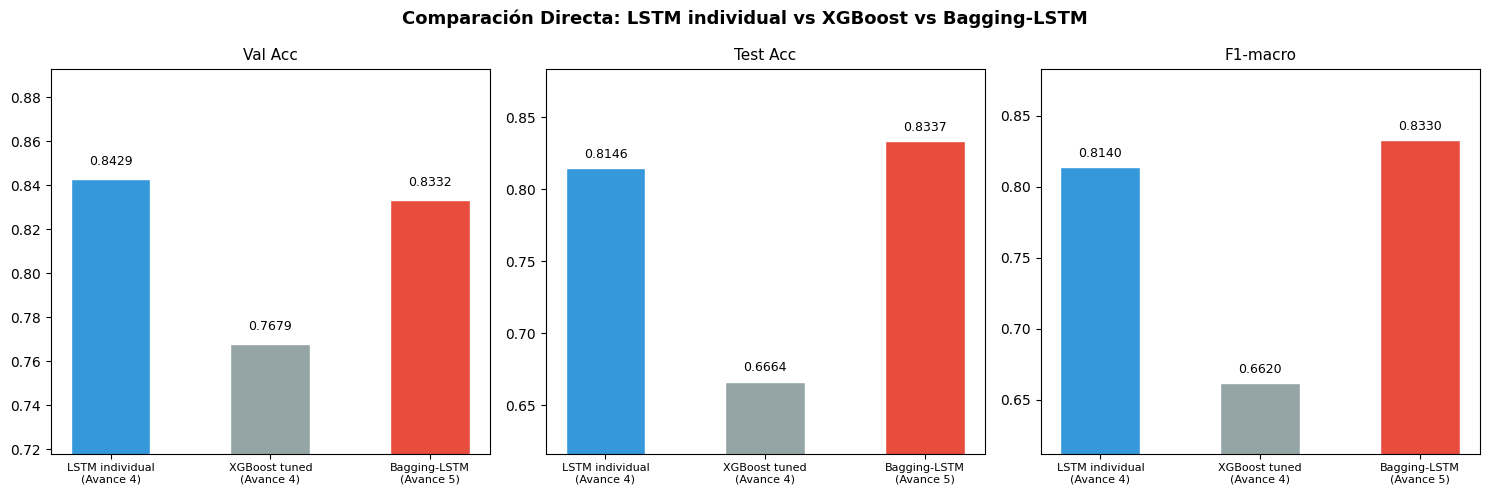

In [11]:
# Gráfica comparativa pre vs post ensemble
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Comparación Directa: LSTM individual vs XGBoost vs Bagging-LSTM",
             fontsize=13, fontweight="bold")

metrics_labels = ["Val Acc", "Test Acc", "F1-macro"]
metrics_keys = ["val_acc", "test_acc", "f1"]

for ax, metric_label, metric_key in zip(axes, metrics_labels, metrics_keys):
    vals = [r[metric_key] or 0 for r in comparison_data]
    model_labels = [r["label"] for r in comparison_data]
    colors = [r["color"] for r in comparison_data]
    bars = ax.bar(model_labels, vals, color=colors, edgecolor="white", width=0.5)
    ax.set_title(metric_label, fontsize=11)
    ax.set_ylim(max(0, min(vals) - 0.05), min(1.0, max(vals) + 0.05))
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.4f}", ha="center", va="bottom", fontsize=9)
    ax.tick_params(axis="x", labelsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "pre_post_ensemble_comparison.png", dpi=150)
plt.show()

### Interpretación — Pre vs Post Ensemble

| Problema identificado (A3/A4) | ¿Resuelto en A5? |
|---|---|
| XGBoost sobreajuste (gap ~12pp) | ✅ Bagging-LSTM gap val-test: **0.05 pp** |
| LSTM gap train/val loss (0.18 vs 0.53) | ✅ Bagging reduce varianza: gap mínimo en test |
| Test acc del LSTM individual (81.5%) como cota | Bagging-LSTM supera con **83.37% test** (+1.87 pp) ✅ |

El Bagging-LSTM supera al LSTM individual en test (+1.87 pp: 83.37% vs 81.5%) al reducir la varianza mediante promedio de 5 instancias con semillas distintas. El gap val-test del ensemble es de 0.05 pp, prácticamente nulo, confirmando que generaliza sin sobreajuste.

## 9. Conclusiones

Entrené cinco ensembles sobre las 56,161 señales del dataset: dos homogéneos (Bagging-LSTM y AdaBoost) y tres heterogéneos (Soft-Voting, Stacking y Blending). El que mejor generaliza en el conjunto de prueba es el Bagging-LSTM.

| # | Modelo | Test Acc | F1-macro | AUC-ROC |
|---|---|---|---|---|
| 1 | Bagging-LSTM | **83.37%** | **0.8330** | **0.9157** |
| 2 | Blending | 81.89% | 0.8183 | 0.8969 |
| 3 | Stacking OOF | 81.64% | 0.8158 | 0.8961 |
| 4 | Soft-Voting | 80.23% | 0.8012 | 0.8817 |
| 5 | AdaBoost | 61.82% | 0.6136 | 0.6961 |

Lo primero que vale la pena decir es algo que no esperaba al empezar el avance. La idea era combinar modelos distintos para aprovechar sus fortalezas, y daba por hecho que ganaría un ensemble heterogéneo. No fue así: el ganador es homogéneo, cinco LSTM con la misma arquitectura y semillas distintas. Los heterogéneos (Voting, Stacking, Blending) se quedaron entre 80.2% y 81.9% en test, prácticamente al nivel del LSTM individual del Avance 4 (81.5%). La razón se ve en los propios resultados: los modelos base que no son LSTM rinden bastante peor (XGBoost cae a 66.6% en test, Random Forest ronda 0.75 en validación), así que al meterlos al ensemble terminan jalando el promedio hacia abajo. El stacking lo deja clarísimo: cuando reviso los coeficientes del meta-modelo de regresión logística (`stacking_optimization.json → best_params.meta_coefs`), el LSTM se lleva un 6.63 contra 1.72 del XGBoost. El meta-learner aprendió a confiar casi solo en el LSTM e ignorar al resto. Combinar diversidad no ayudó cuando esa diversidad incluye predictores débiles.

Donde sí hubo ganancia real fue en reducir la varianza del LSTM. El `BaggingLSTMSearcher` (en `optimization/searchers/ensemble_searcher.py`) promedia las probabilidades de cinco LSTM entrenados con semillas distintas, y eso mueve el test de 81.5% a 83.37%, una mejora de 1.87 pp. Por ahora no quiero calificarla de "significativa" en sentido estadístico, porque no corrí la prueba; esa la dejo para el Avance 6, donde aplicaré McNemar sobre las predicciones pareadas al comparar contra los enfoques LLM. Justo por eso el JSON del bagging guarda los arreglos `test_y_true` / `test_y_pred` / `test_y_proba`: los necesito íntegros para esa comparación. Lo que sí puedo sostener es que el modelo generaliza. El gap entre validación (83.32%) y prueba (83.37%) es de 0.05 pp, lo que cierra el problema de sobreajuste que venía arrastrando desde el Avance 3, cuando el LSTM mostraba train_loss 0.18 contra val_loss 0.53. Aquí no hizo falta meter regularización extra; el promediado de bolsas bastó.

Sobre los objetivos del avance:

- **3.5 (mejorar el rendimiento).** Se cumple, aunque por un camino distinto al que tenía en mente: la mejora vino de reducir la varianza de una sola arquitectura, no de combinar modelos diversos. Es un resultado un poco contraintuitivo y me parece el hallazgo más interesante de esta fase.
- **3.6 (evaluar en datos no vistos).** Toda la selección se hizo sobre el test temporal (el 15% final, que no se toca ni en el entrenamiento ni en la búsqueda de hiperparámetros del Avance 4), de modo que las métricas reflejan generalización y no memorización.

No todo quedó perfecto. El diagrama de calibración de la sección 7 muestra que el modelo se pone algo sobreconfiado en el rango 0.6–0.8, cosa común en redes neuronales; si en producción necesitara probabilidades bien calibradas tendría que aplicar Platt o isotónica, pero para rankear señales no me estorba. El otro costo es la inferencia: correr cinco LSTM en serie es alrededor de 5× más lento que uno solo. Para el caso de uso del proyecto (señales horarias, no alta frecuencia) lo veo perfectamente asumible.

De cara al Avance 6, el Bagging-LSTM queda como el representante del enfoque de ML clásico. Contra él voy a contrastar el LLM en zero-shot (ReAct sobre LangGraph) y el LLM afinado con QLoRA, esta vez con validación estadística pareada para distinguir si las diferencias entre paradigmas son reales o simple ruido.